Prueba

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from hyperopt import hp, fmin, tpe, Trials, STATUS_OK
from keras.models import Sequential
from keras.layers import Dense, Dropout, GRU, InputLayer, Flatten, LSTM
from keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
import os
from datetime import datetime, timedelta
import plotly.express as px
import plotly.graph_objects as go
import random


LEER DATASET

In [2]:
import pandas as pd

datosMLP = pd.read_csv("C:\\Users\\wamt1\\OneDrive\\Escritorio\\computadorNuevo2\\datosNarmax\\24pasos_mlp_pollution.csv")
datosLSTM = pd.read_csv("C:\\Users\\wamt1\\OneDrive\\Escritorio\\computadorNuevo2\\datosNarmax\\24pasos_lstm_pollution.csv")
datosGRU = pd.read_csv("C:\\Users\\wamt1\\OneDrive\\Escritorio\\computadorNuevo2\\datosNarmax\\24pasos_gru_pollution.csv")

datosMLP['date'] = pd.to_datetime(datosMLP['date'])
datosLSTM['date'] = pd.to_datetime(datosLSTM['date'])
datosGRU['date'] = pd.to_datetime(datosGRU['date'])

# Se establece la columna date como index
datosMLP.set_index('date', inplace=True)
datosLSTM.set_index('date', inplace=True)
datosGRU.set_index('date', inplace=True)


In [3]:
datosMLP.tail()

,pollution,dew,temp,press,wnd_dir,wnd_spd,e
date,,,,,,,
2014-12-31 19:00:00,-1.009952,-1.702068,-1.106944,1.679851,0.694538,4.054828,-0.672097
2014-12-31 20:00:00,-0.988008,-1.632347,-1.187734,1.679851,0.694538,4.168890,-0.606625
2014-12-31 21:00:00,-0.988008,-1.632347,-1.187734,1.679851,0.694538,4.265479,-0.597509
2014-12-31 22:00:00,-1.009952,-1.632347,-1.268524,1.679851,0.694538,4.344399,-0.427131
2014-12-31 23:00:00,-0.966063,-1.562627,-1.187734,1.679851,0.694538,4.405847,-0.381507


In [4]:
datosLSTM.tail()

,pollution,dew,temp,press,wnd_dir,wnd_spd,e
date,,,,,,,
2014-12-31 19:00:00,-1.009952,-1.702068,-1.106944,1.679851,0.694538,4.054828,-0.826614
2014-12-31 20:00:00,-0.988008,-1.632347,-1.187734,1.679851,0.694538,4.168890,-0.783249
2014-12-31 21:00:00,-0.988008,-1.632347,-1.187734,1.679851,0.694538,4.265479,-0.735042
2014-12-31 22:00:00,-1.009952,-1.632347,-1.268524,1.679851,0.694538,4.344399,-0.667675
2014-12-31 23:00:00,-0.966063,-1.562627,-1.187734,1.679851,0.694538,4.405847,-0.575324


In [5]:
datosGRU.tail()

,pollution,dew,temp,press,wnd_dir,wnd_spd,e
date,,,,,,,
2014-12-31 19:00:00,-1.009952,-1.702068,-1.106944,1.679851,0.694538,4.054828,-0.884729
2014-12-31 20:00:00,-0.988008,-1.632347,-1.187734,1.679851,0.694538,4.168890,-0.762506
2014-12-31 21:00:00,-0.988008,-1.632347,-1.187734,1.679851,0.694538,4.265479,-0.682858
2014-12-31 22:00:00,-1.009952,-1.632347,-1.268524,1.679851,0.694538,4.344399,-0.558328
2014-12-31 23:00:00,-0.966063,-1.562627,-1.187734,1.679851,0.694538,4.405847,-0.488613


In [6]:
#Se verifica que el index está en formato de dato "datetime64"
print("El index del dataframe MLP input es un tipo de dato: ", datosMLP.index.dtype)
print("El index del dataframe LSTM input es un tipo de dato: ", datosLSTM.index.dtype)
print("El index del dataframe GRU input es un tipo de dato: ", datosGRU.index.dtype)


El index del dataframe MLP input es un tipo de dato:  datetime64[ns]
El index del dataframe LSTM input es un tipo de dato:  datetime64[ns]
El index del dataframe GRU input es un tipo de dato:  datetime64[ns]


Se establece el formato de datos de entrada para redes GRU y LSTM, es decir [observaciones, retardos, caracteristicas]

In [7]:
futuros = 24
pasados  = 48

In [8]:
datosMLPX = []
datosMLPY = []
for i in range(pasados, len(datosMLP) - futuros + 1):
  datosMLPX.append(datosMLP.iloc[i-pasados:i, 0:datosMLP.shape[1]])
  datosMLPY.append(datosMLP.iloc[i+futuros-1:i+futuros, 0])


In [9]:
datosLSTMX = []
datosLSTMY = []
for i in range(pasados, len(datosLSTM) - futuros + 1):
  datosLSTMX.append(datosLSTM.iloc[i-pasados:i, 0:datosLSTM.shape[1]])
  datosLSTMY.append(datosLSTM.iloc[i+futuros-1:i+futuros, 0])

In [10]:
datosGRUX = []
datosGRUY = []
for i in range(pasados, len(datosGRU) - futuros + 1):
  datosGRUX.append(datosGRU.iloc[i-pasados:i, 0:datosGRU.shape[1]])
  datosGRUY.append(datosGRU.iloc[i+futuros-1:i+futuros, 0])

In [11]:
# Convertir las listas en arrays numpy
datosMLPX = np.array(datosMLPX)
datosMLPY = np.array(datosMLPY)

# Ver las dimensiones (shape) de los arrays
print("Dimensiones de MLP X:", datosMLPX.shape)  
print("Dimensiones de MLP Y:", datosMLPY.shape)  

Dimensiones de MLP X: (43729, 48, 7)
Dimensiones de MLP Y: (43729, 1)


In [12]:
# Convertir las listas en arrays numpy
datosLSTMX = np.array(datosLSTMX)
datosLSTMY = np.array(datosLSTMY)

# Ver las dimensiones (shape) de los arrays
print("Dimensiones de LSTM X:", datosLSTMX.shape)  
print("Dimensiones de LSTM Y:", datosLSTMY.shape)  

Dimensiones de LSTM X: (43729, 48, 7)
Dimensiones de LSTM Y: (43729, 1)


In [13]:
# Convertir las listas en arrays numpy
datosGRUX = np.array(datosGRUX)
datosGRUY = np.array(datosGRUY)

# Ver las dimensiones (shape) de los arrays
print("Dimensiones de GRU X:", datosGRUX.shape)  
print("Dimensiones de GRU Y:", datosGRUY.shape)  

Dimensiones de GRU X: (43729, 48, 7)
Dimensiones de GRU Y: (43729, 1)


In [14]:
inputs = datosMLPX.shape[1] * datosMLPX.shape[2]
datosMLPX = datosMLPX.reshape(datosMLPX.shape[0], inputs)

In [15]:
datosMLPX

array([[ 0.31768099, -1.2140229 , -1.26852411, ...,  0.69453847,
        -0.21845241, -0.540976  ],
       [ 0.52615226, -1.14430217, -1.26852411, ...,  0.69453847,
        -0.18331127, -0.37019954],
       [ 0.64684616, -0.86541928, -1.34931411, ...,  0.69453847,
        -0.0692498 , -0.5048696 ],
       ...,
       [ 2.45725463, -0.79569856, -0.78378415, ...,  0.69453847,
        -0.0692498 , -1.00521749],
       [ 2.64378156, -0.79569856, -1.10694413, ...,  0.69453847,
         0.12373201, -1.17196322],
       [ 2.87419719, -0.79569856, -1.26852411, ...,  0.69453847,
         0.26410026, -1.0425467 ]])

Se dividen nuevamente los conjuntos de datos

In [16]:
from sklearn.model_selection import train_test_split

# Dividir el conjunto de datos en entrenamiento y prueba
trainMLPX, testMLPX = train_test_split(datosMLPX, test_size=0.3, shuffle=False)

# Luego, dividir el conjunto de prueba en conjuntos de prueba y validación
testMLPX, valMLPX = train_test_split(testMLPX, test_size=0.33, shuffle=False)

print("Las dimensiones de trainMLPX son: ", trainMLPX.shape)
print("Las dimensiones de testMLPX son: ", testMLPX.shape)
print("Las dimensiones de valMLPX son: ", valMLPX.shape)


Las dimensiones de trainMLPX son:  (30610, 336)
Las dimensiones de testMLPX son:  (8789, 336)
Las dimensiones de valMLPX son:  (4330, 336)


In [17]:
from sklearn.model_selection import train_test_split

# Dividir el conjunto de datos en entrenamiento y prueba
trainLSTMX, testLSTMX = train_test_split(datosLSTMX, test_size=0.3, shuffle=False)

# Luego, dividir el conjunto de prueba en conjuntos de prueba y validación
testLSTMX, valLSTMX = train_test_split(testLSTMX, test_size=0.33, shuffle=False)

print("Las dimensiones de trainLSTMX son: ", trainLSTMX.shape)
print("Las dimensiones de testLSTMX son: ", testLSTMX.shape)
print("Las dimensiones de valLSTMX son: ", valLSTMX.shape)

Las dimensiones de trainLSTMX son:  (30610, 48, 7)
Las dimensiones de testLSTMX son:  (8789, 48, 7)
Las dimensiones de valLSTMX son:  (4330, 48, 7)


In [18]:
from sklearn.model_selection import train_test_split

# Dividir el conjunto de datos en entrenamiento y prueba
trainGRUX, testGRUX = train_test_split(datosGRUX, test_size=0.3, shuffle=False)

# Luego, dividir el conjunto de prueba en conjuntos de prueba y validación
testGRUX, valGRUX = train_test_split(testGRUX, test_size=0.33, shuffle=False)

print("Las dimensiones de trainGRUX son: ", trainGRUX.shape)
print("Las dimensiones de testGRUX son: ", testGRUX.shape)
print("Las dimensiones de valGRUX son: ", valGRUX.shape)

Las dimensiones de trainGRUX son:  (30610, 48, 7)
Las dimensiones de testGRUX son:  (8789, 48, 7)
Las dimensiones de valGRUX son:  (4330, 48, 7)


In [19]:
from sklearn.model_selection import train_test_split

# Dividir el conjunto de datos en entrenamiento y prueba
trainY, testY = train_test_split(datosMLPY, test_size=0.3, shuffle=False)

# Luego, dividir el conjunto de prueba en conjuntos de prueba y validación
testY, valY = train_test_split(testY, test_size=0.33, shuffle=False)

print("Las dimensiones de trainY son: ", trainY.shape)
print("Las dimensiones de testY son: ", testY.shape)
print("Las dimensiones de valY son: ", valY.shape)

Las dimensiones de trainY son:  (30610, 1)
Las dimensiones de testY son:  (8789, 1)
Las dimensiones de valY son:  (4330, 1)


Se crean métricas para medir desempeño

In [20]:
import tensorflow.keras.backend as K

def smape(y_true, y_pred):
    """
    Define la función SMAPE (Error Porcentual Absoluto Medio Simétrico).
    """
    summ = K.abs(y_true) + K.abs(y_pred)
    smape_val = K.abs(y_pred - y_true) / summ * 2.0
    return K.mean(smape_val, axis=-1)

def rmse(y_true, y_pred):
    return K.sqrt(K.mean(K.square(y_pred - y_true)))

def ia(y_true, y_pred):
    numerator = K.sum(K.abs(y_true - y_pred))
    denominator = K.sum(K.abs(y_true - K.mean(y_true)) + K.abs(y_pred - K.mean(y_true)))
    return 1 - (numerator / denominator)

Se define el index del conjunto de validación para utilizarlo posteriormente para graficar.

In [21]:
# Fecha y hora de término del conjunto de datos de prueba
end_date = datosMLP.index[-1]
n_observations = valY.shape[0]  # Cambia esto al número de observaciones en tu conjunto de prueba

# Calcular la fecha y hora de inicio
start_date = end_date - timedelta(hours = (n_observations - 1))

# Crear la serie de fechas y horas
val_date = pd.date_range(start=start_date, end=end_date, freq='1H')

val_date

C:\Users\wamt1\AppData\Local\Temp\ipykernel_5712\196214621.py:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  val_date = pd.date_range(start=start_date, end=end_date, freq='1H')


DatetimeIndex(['2014-07-04 14:00:00', '2014-07-04 15:00:00',
               '2014-07-04 16:00:00', '2014-07-04 17:00:00',
               '2014-07-04 18:00:00', '2014-07-04 19:00:00',
               '2014-07-04 20:00:00', '2014-07-04 21:00:00',
               '2014-07-04 22:00:00', '2014-07-04 23:00:00',
               ...
               '2014-12-31 14:00:00', '2014-12-31 15:00:00',
               '2014-12-31 16:00:00', '2014-12-31 17:00:00',
               '2014-12-31 18:00:00', '2014-12-31 19:00:00',
               '2014-12-31 20:00:00', '2014-12-31 21:00:00',
               '2014-12-31 22:00:00', '2014-12-31 23:00:00'],
              dtype='datetime64[ns]', length=4330, freq='h')

Se guardan los índices de las observaciones a utilizar para predecir

In [22]:
indices = []
for i in range(pasados, len(datosMLP) - futuros + 1):
  indices.append(datosMLP.index[i+futuros-2])

# Modelos


## MLP

In [23]:
'''
space = {
    'layers': hp.quniform('layers', 1, 4, 1),  # Cantidad de capas GRU (1, 2, 3, 4)
    'units': hp.choice('units', [8, 16, 32, 64, 128]),  # Número de unidades GRU
    'activation': hp.choice('activation', ['tanh', 'sigmoid', 'relu', 'linear']),  # Funciones de activación
    'dropout': hp.quniform('dropout', 0, 0.5, 0.1),  # Dropout entre 0 y 0.5, con pasos de 0.1
    'learning_rate': hp.loguniform('learning_rate', np.log(0.000001), np.log(0.01)),  # Tasa de aprendizaje logarítmica
    'epochs': hp.choice('epochs', [8, 16, 32, 64, 128, 256]),  # Número de épocas de entrenamiento
    'batch': hp.choice('batch', [8, 16, 32, 64, 128, 256])  # Tamaño de batch
}
'''

"\nspace = {\n    'layers': hp.quniform('layers', 1, 4, 1),  # Cantidad de capas GRU (1, 2, 3, 4)\n    'units': hp.choice('units', [8, 16, 32, 64, 128]),  # Número de unidades GRU\n    'activation': hp.choice('activation', ['tanh', 'sigmoid', 'relu', 'linear']),  # Funciones de activación\n    'dropout': hp.quniform('dropout', 0, 0.5, 0.1),  # Dropout entre 0 y 0.5, con pasos de 0.1\n    'learning_rate': hp.loguniform('learning_rate', np.log(0.000001), np.log(0.01)),  # Tasa de aprendizaje logarítmica\n    'epochs': hp.choice('epochs', [8, 16, 32, 64, 128, 256]),  # Número de épocas de entrenamiento\n    'batch': hp.choice('batch', [8, 16, 32, 64, 128, 256])  # Tamaño de batch\n}\n"

In [24]:
modelMLP = Sequential()
modelMLP.add(InputLayer(input_shape=(testMLPX.shape[1],)))

modelMLP.add(Dense(units=64, activation="linear"))
modelMLP.add(Dropout(0.4))

modelMLP.add(Dense(1))

opt = Adam(learning_rate=0.009726326397617627)

modelMLP.compile(optimizer=opt, loss='mse', metrics=["mae", smape, rmse, ia])

modelMLP.summary()








c:\Users\wamt1\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\input_layer.py:26: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        21,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,633 (84.50 KB)

 Trainable params: 21,633 (84.50 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
np.random.seed(42)
random.seed(42)

tf.random.set_seed(42)


early_stopping = EarlyStopping(monitor='val_loss', patience=15, verbose=1, restore_best_weights= True)

historyMLP = modelMLP.fit(testMLPX, testY, epochs=128,
                        validation_split=0.3,
                        verbose = 2, batch_size=128, callbacks=[early_stopping])

prediccionMLP = modelMLP.predict(valMLPX)


Epoch 1/128
49/49 - 3s - 55ms/step - ia: 0.3390 - loss: 4.2738 - mae: 1.3760 - rmse: 1.7663 - smape: 1.3616 - val_ia: 0.3060 - val_loss: 0.4917 - val_mae: 0.5164 - val_rmse: 0.6547 - val_smape: 1.2662
Epoch 2/128
49/49 - 0s - 9ms/step - ia: 0.4158 - loss: 0.9343 - mae: 0.7162 - rmse: 0.9551 - smape: 1.2483 - val_ia: 0.3200 - val_loss: 0.4603 - val_mae: 0.5062 - val_rmse: 0.6380 - val_smape: 1.2374
Epoch 3/128
49/49 - 0s - 4ms/step - ia: 0.4274 - loss: 0.9026 - mae: 0.7032 - rmse: 0.9386 - smape: 1.2355 - val_ia: 0.3209 - val_loss: 0.4555 - val_mae: 0.5002 - val_rmse: 0.6331 - val_smape: 1.2200
Epoch 4/128
49/49 - 0s - 6ms/step - ia: 0.4296 - loss: 0.8933 - mae: 0.6978 - rmse: 0.9343 - smape: 1.2247 - val_ia: 0.3238 - val_loss: 0.4580 - val_mae: 0.4966 - val_rmse: 0.6316 - val_smape: 1.2042
Epoch 5/128
49/49 - 0s - 4ms/step - ia: 0.4324 - loss: 0.8916 - mae: 0.6951 - rmse: 0.9324 - smape: 1.2216 - val_ia: 0.3194 - val_loss: 0.4599 - val_mae: 0.5064 - val_rmse: 0.6375 - val_smape: 1.2586

In [26]:
metricasMLP = modelMLP.evaluate(valMLPX, valY, verbose=2)
print(f"Métricas en el conjunto de validación: {metricasMLP}")

136/136 - 0s - 2ms/step - ia: 0.2682 - loss: 0.7882 - mae: 0.6786 - rmse: 0.7607 - smape: 1.3110
Métricas en el conjunto de validación: [0.7881878614425659, 0.6786466836929321, 1.3109687566757202, 0.760701596736908, 0.26819610595703125]


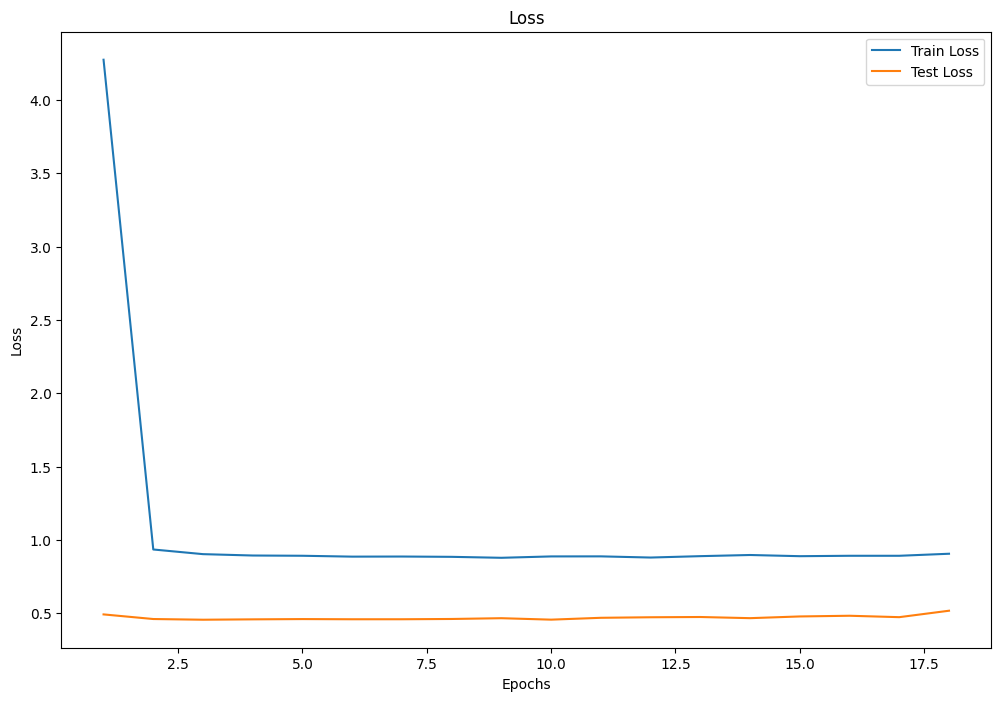

In [27]:
historyMLP = historyMLP.history

ejeXMLP = range(1, len(historyMLP['loss']) + 1)

plt.figure(figsize=(12, 8))
plt.plot(ejeXMLP, historyMLP['loss'], label='Train Loss')
plt.plot(ejeXMLP, historyMLP['val_loss'], label='Test Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [28]:
# Obtener el último valor de la pérdida de entrenamiento
ultimo_train_loss = historyMLP['loss'][-1]

# Obtener el último valor de la pérdida de validación
ultimo_val_loss = historyMLP['val_loss'][-1]

# Imprimir los valores finales
print(f'Último valor de Train Loss: {ultimo_train_loss}')
print(f'Último valor de Test Loss: {ultimo_val_loss}')

Último valor de Train Loss: 0.9053383469581604
Último valor de Test Loss: 0.5168644785881042


In [ ]:
# Crea un DataFrame con los datos originales y los predichos
df = pd.DataFrame({'Originales': valY.flatten(), 'Predichos': prediccionMLP.flatten()})
df.index = val_date

fecha_inicio = df.index[0]
fecha_fin = df.index[-1]


fig = px.line(df, title='Valores Originales vs Valores Predichos')
fig.update_xaxes(rangeslider_visible=True, title='Índice de la Muestra', range=[fecha_inicio, fecha_fin])
fig.update_yaxes(title='Valores')


fig.add_trace(go.Scatter(x=df.index, y=[0] * len(df), mode='lines', name='Igualdad', line=dict(color='black', dash='dash')))
dfMLP = df
fig.show()

In [30]:
dfMLP.to_csv('C:\\Users\\wamt1\\OneDrive\\Escritorio\\computadorNuevo2\\evaluacionNarmax\\4824pasos_mlp_pollution.csv', index=True)

In [31]:
modelMLP.save('C:\\Users\\wamt1\\OneDrive\\Escritorio\\computadorNuevo2\\modelosEntranadosNarmax\\4824pasos_mlp_pollution.h5')

## LSTM

In [32]:
'''
space = {
    'layers': hp.quniform('layers', 1, 4, 1),  # Cantidad de capas GRU (1, 2, 3, 4)
    'units': hp.choice('units', [8, 16, 32, 64, 128]),  # Número de unidades GRU
    'activation': hp.choice('activation', ['tanh', 'sigmoid', 'relu', 'linear']),  # Funciones de activación
    'dropout': hp.quniform('dropout', 0, 0.5, 0.1),  # Dropout entre 0 y 0.5, con pasos de 0.1
    'learning_rate': hp.loguniform('learning_rate', np.log(0.000001), np.log(0.01)),  # Tasa de aprendizaje logarítmica
    'epochs': hp.choice('epochs', [8, 16, 32, 64, 128, 256]),  # Número de épocas de entrenamiento
    'batch': hp.choice('batch', [8, 16, 32, 64, 128, 256])  # Tamaño de batch
}
'''

"\nspace = {\n    'layers': hp.quniform('layers', 1, 4, 1),  # Cantidad de capas GRU (1, 2, 3, 4)\n    'units': hp.choice('units', [8, 16, 32, 64, 128]),  # Número de unidades GRU\n    'activation': hp.choice('activation', ['tanh', 'sigmoid', 'relu', 'linear']),  # Funciones de activación\n    'dropout': hp.quniform('dropout', 0, 0.5, 0.1),  # Dropout entre 0 y 0.5, con pasos de 0.1\n    'learning_rate': hp.loguniform('learning_rate', np.log(0.000001), np.log(0.01)),  # Tasa de aprendizaje logarítmica\n    'epochs': hp.choice('epochs', [8, 16, 32, 64, 128, 256]),  # Número de épocas de entrenamiento\n    'batch': hp.choice('batch', [8, 16, 32, 64, 128, 256])  # Tamaño de batch\n}\n"

In [33]:
modelLSTM = Sequential()
modelLSTM.add(InputLayer(input_shape=(testLSTMX.shape[1], testLSTMX.shape[2])))


modelLSTM.add(LSTM(units=128, activation="sigmoid", return_sequences=False))
modelLSTM.add(Dropout(0.2))

modelLSTM.add(Dense(1))


opt = Adam(learning_rate=0.0002707756079796208)
modelLSTM.compile(optimizer=opt, loss='mse', metrics=["mae", smape, rmse, ia])

modelLSTM.summary()



c:\Users\wamt1\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\input_layer.py:26: UserWarning:

Argument `input_shape` is deprecated. Use `shape` instead.



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 128)            │        69,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 69,761 (272.50 KB)

 Trainable params: 69,761 (272.50 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
np.random.seed(42)
random.seed(42)

tf.random.set_seed(42)


early_stopping = EarlyStopping(monitor='val_loss', patience=15, verbose=1, restore_best_weights= True)

historyLSTM = modelLSTM.fit(testLSTMX, testY, epochs=128,
                        validation_split=0.3,
                        verbose = 2, batch_size=128, callbacks=[early_stopping])

prediccionLSTM = modelLSTM.predict(valLSTMX)

Epoch 1/128
49/49 - 7s - 150ms/step - ia: 0.2530 - loss: 1.2742 - mae: 0.8249 - rmse: 1.1128 - smape: 1.4576 - val_ia: 0.2630 - val_loss: 0.4967 - val_mae: 0.5343 - val_rmse: 0.6542 - val_smape: 1.4505
Epoch 2/128
49/49 - 4s - 72ms/step - ia: 0.2793 - loss: 1.0576 - mae: 0.7668 - rmse: 1.0165 - smape: 1.4353 - val_ia: 0.2755 - val_loss: 0.4667 - val_mae: 0.5198 - val_rmse: 0.6390 - val_smape: 1.3776
Epoch 3/128
49/49 - 3s - 71ms/step - ia: 0.3320 - loss: 0.9917 - mae: 0.7465 - rmse: 0.9874 - smape: 1.3690 - val_ia: 0.2882 - val_loss: 0.4488 - val_mae: 0.5019 - val_rmse: 0.6253 - val_smape: 1.2749
Epoch 4/128
49/49 - 4s - 77ms/step - ia: 0.3661 - loss: 0.9698 - mae: 0.7382 - rmse: 0.9764 - smape: 1.3113 - val_ia: 0.2974 - val_loss: 0.4434 - val_mae: 0.4977 - val_rmse: 0.6231 - val_smape: 1.2393
Epoch 5/128
49/49 - 5s - 111ms/step - ia: 0.3923 - loss: 0.9541 - mae: 0.7272 - rmse: 0.9669 - smape: 1.2760 - val_ia: 0.3040 - val_loss: 0.4423 - val_mae: 0.4959 - val_rmse: 0.6229 - val_smape: 

In [35]:
metricasLSTM = modelLSTM.evaluate(valLSTMX, valY, verbose=2)
print(f"Métricas en el conjunto de validación: {metricasLSTM}")

136/136 - 2s - 11ms/step - ia: 0.2662 - loss: 0.7824 - mae: 0.6647 - rmse: 0.7488 - smape: 1.2658
Métricas en el conjunto de validación: [0.7823969721794128, 0.6646831631660461, 1.2658289670944214, 0.7488448619842529, 0.2661515772342682]


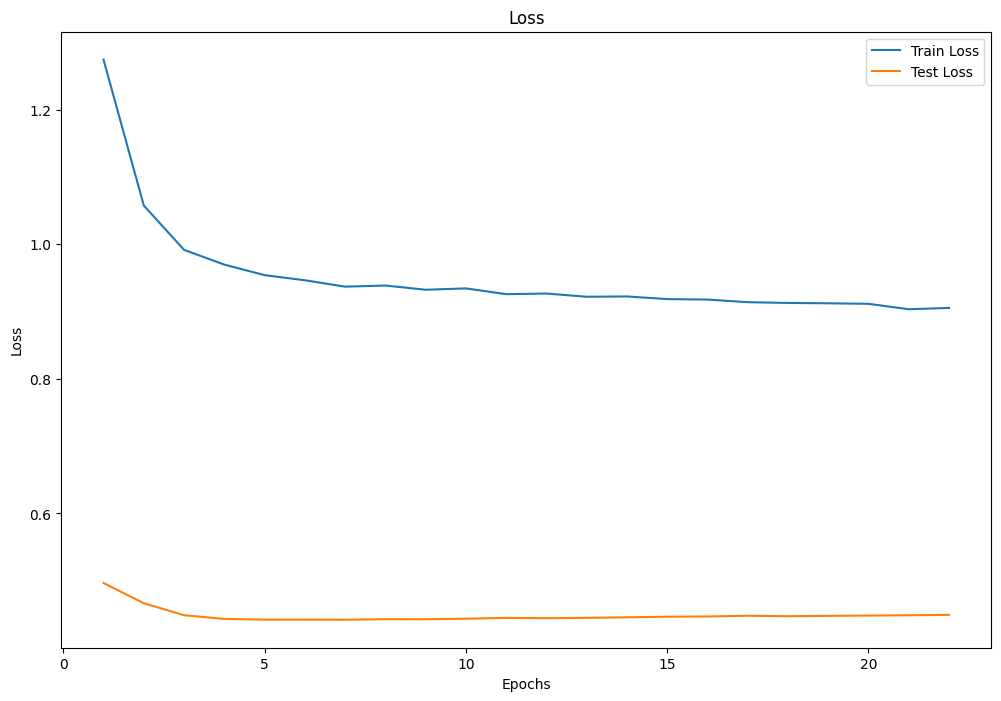

In [36]:
historyLSTM = historyLSTM.history

ejeXLSTM = range(1, len(historyLSTM['loss']) + 1)
plt.figure(figsize=(12, 8))
plt.plot(ejeXLSTM, historyLSTM['loss'], label='Train Loss')
plt.plot(ejeXLSTM, historyLSTM['val_loss'], label='Test Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [37]:
# Obtener el último valor de la pérdida de entrenamiento
ultimo_train_loss = historyLSTM['loss'][-1]

# Obtener el último valor de la pérdida de validación
ultimo_val_loss = historyLSTM['val_loss'][-1]

# Imprimir los valores finales
print(f'Último valor de Train Loss: {ultimo_train_loss}')
print(f'Último valor de Test Loss: {ultimo_val_loss}')

Último valor de Train Loss: 0.9054355025291443
Último valor de Test Loss: 0.4493883550167084


In [ ]:
# Crea un DataFrame con los datos originales y los predichos
df = pd.DataFrame({'Originales': valY.flatten(), 'Predichos': prediccionLSTM.flatten()})
df.index = val_date

fecha_inicio = df.index[0]
fecha_fin = df.index[-1]


fig = px.line(df, title='Valores Originales vs Valores Predichos')
fig.update_xaxes(rangeslider_visible=True, title='Índice de la Muestra', range=[fecha_inicio, fecha_fin])
fig.update_yaxes(title='Valores')


fig.add_trace(go.Scatter(x=df.index, y=[0] * len(df), mode='lines', name='Igualdad', line=dict(color='black', dash='dash')))
dfLSTM = df
fig.show()


In [39]:
dfLSTM.to_csv('C:\\Users\\wamt1\\OneDrive\\Escritorio\\computadorNuevo2\\evaluacionNarmax\\4824pasos_lstm_pollution.csv', index=True)

In [40]:
modelLSTM.save('C:\\Users\\wamt1\\OneDrive\\Escritorio\\computadorNuevo2\\modelosEntranadosNarmax\\4824pasos_lstm_pollution.h5')

## GRU

In [41]:
'''
space = {
    'layers': hp.quniform('layers', 1, 4, 1),  # Cantidad de capas GRU (1, 2, 3, 4)
    'units': hp.choice('units', [8, 16, 32, 64, 128]),  # Número de unidades GRU
    'activation': hp.choice('activation', ['tanh', 'sigmoid', 'relu', 'linear']),  # Funciones de activación
    'dropout': hp.quniform('dropout', 0, 0.5, 0.1),  # Dropout entre 0 y 0.5, con pasos de 0.1
    'learning_rate': hp.loguniform('learning_rate', np.log(0.000001), np.log(0.01)),  # Tasa de aprendizaje logarítmica
    'epochs': hp.choice('epochs', [8, 16, 32, 64, 128, 256]),  # Número de épocas de entrenamiento
    'batch': hp.choice('batch', [8, 16, 32, 64, 128, 256])  # Tamaño de batch
}
'''

"\nspace = {\n    'layers': hp.quniform('layers', 1, 4, 1),  # Cantidad de capas GRU (1, 2, 3, 4)\n    'units': hp.choice('units', [8, 16, 32, 64, 128]),  # Número de unidades GRU\n    'activation': hp.choice('activation', ['tanh', 'sigmoid', 'relu', 'linear']),  # Funciones de activación\n    'dropout': hp.quniform('dropout', 0, 0.5, 0.1),  # Dropout entre 0 y 0.5, con pasos de 0.1\n    'learning_rate': hp.loguniform('learning_rate', np.log(0.000001), np.log(0.01)),  # Tasa de aprendizaje logarítmica\n    'epochs': hp.choice('epochs', [8, 16, 32, 64, 128, 256]),  # Número de épocas de entrenamiento\n    'batch': hp.choice('batch', [8, 16, 32, 64, 128, 256])  # Tamaño de batch\n}\n"

In [42]:
modelGRU = Sequential()
modelGRU.add(InputLayer(input_shape=(testGRUX.shape[1], testGRUX.shape[2])))

modelGRU.add(GRU(units=8, activation="linear", return_sequences=False))
modelGRU.add(Dropout(0.3))

modelGRU.add(Dense(1))


opt = Adam(learning_rate=0.001217652235385441)
modelGRU.compile(optimizer=opt, loss='mse', metrics=["mae", smape, rmse, ia])

modelGRU.summary()




c:\Users\wamt1\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\input_layer.py:26: UserWarning:

Argument `input_shape` is deprecated. Use `shape` instead.



Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 8)              │           408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 417 (1.63 KB)

 Trainable params: 417 (1.63 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
np.random.seed(42)
random.seed(42)

tf.random.set_seed(42)

early_stopping = EarlyStopping(monitor='val_loss', patience=15, verbose=1, restore_best_weights= True)

historyGRU = modelGRU.fit(testGRUX, testY, epochs=128,
                        validation_split=0.3,
                        verbose = 2, batch_size=128, callbacks=[early_stopping])

prediccionGRU = modelGRU.predict(valGRUX)

Epoch 1/128
49/49 - 4s - 89ms/step - ia: 0.3281 - loss: 2.1494 - mae: 1.1416 - rmse: 1.4504 - smape: 1.3713 - val_ia: 0.3260 - val_loss: 0.5637 - val_mae: 0.5531 - val_rmse: 0.7083 - val_smape: 1.1850
Epoch 2/128
49/49 - 1s - 12ms/step - ia: 0.3612 - loss: 1.3718 - mae: 0.9083 - rmse: 1.1704 - smape: 1.3425 - val_ia: 0.3195 - val_loss: 0.4961 - val_mae: 0.5201 - val_rmse: 0.6614 - val_smape: 1.2134
Epoch 3/128
49/49 - 1s - 12ms/step - ia: 0.3710 - loss: 1.2311 - mae: 0.8516 - rmse: 1.1059 - smape: 1.3247 - val_ia: 0.3173 - val_loss: 0.4762 - val_mae: 0.5072 - val_rmse: 0.6432 - val_smape: 1.2022
Epoch 4/128
49/49 - 1s - 12ms/step - ia: 0.3772 - loss: 1.1784 - mae: 0.8241 - rmse: 1.0845 - smape: 1.3097 - val_ia: 0.3141 - val_loss: 0.4639 - val_mae: 0.5002 - val_rmse: 0.6340 - val_smape: 1.1973
Epoch 5/128
49/49 - 1s - 12ms/step - ia: 0.3909 - loss: 1.0713 - mae: 0.7853 - rmse: 1.0301 - smape: 1.2905 - val_ia: 0.3093 - val_loss: 0.4566 - val_mae: 0.5006 - val_rmse: 0.6315 - val_smape: 1.

In [44]:
metricasGRU = modelGRU.evaluate(valGRUX, valY, verbose=2)
print(f"Métricas en el conjunto de validación: {metricasGRU}")

136/136 - 0s - 3ms/step - ia: 0.2696 - loss: 0.7749 - mae: 0.6627 - rmse: 0.7458 - smape: 1.2733
Métricas en el conjunto de validación: [0.7749059200286865, 0.6627257466316223, 1.2733429670333862, 0.7457871437072754, 0.26955369114875793]


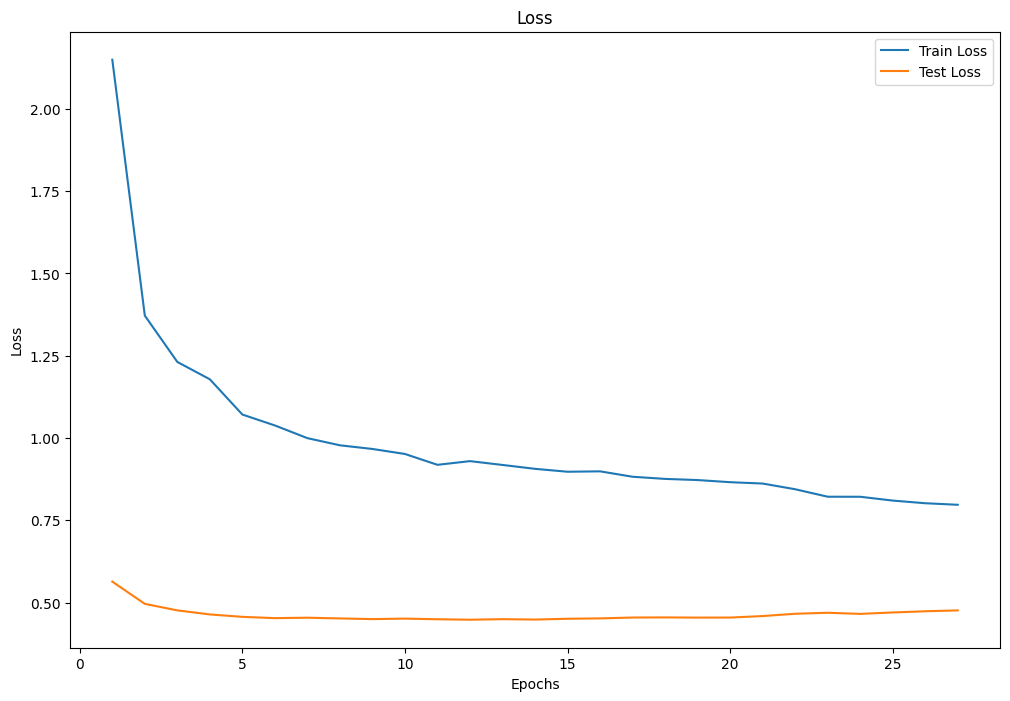

In [45]:
historyGRU = historyGRU.history

ejeXGRU = range(1, len(historyGRU['loss']) + 1)
plt.figure(figsize=(12, 8))
plt.plot(ejeXGRU, historyGRU['loss'], label='Train Loss')
plt.plot(ejeXGRU, historyGRU['val_loss'], label='Test Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [46]:
# Obtener el último valor de la pérdida de entrenamiento
ultimo_train_loss = historyGRU['loss'][-1]

# Obtener el último valor de la pérdida de validación
ultimo_val_loss = historyGRU['val_loss'][-1]

# Imprimir los valores finales
print(f'Último valor de Train Loss: {ultimo_train_loss}')
print(f'Último valor de Test Loss: {ultimo_val_loss}')

Último valor de Train Loss: 0.7971134781837463
Último valor de Test Loss: 0.47620776295661926


In [ ]:
# Crea un DataFrame con los datos originales y los predichos
df = pd.DataFrame({'Originales': valY.flatten(), 'Predichos': prediccionGRU.flatten()})
df.index = val_date

fecha_inicio = df.index[0]
fecha_fin = df.index[-1]


fig = px.line(df, title='Valores Originales vs Valores Predichos')
fig.update_xaxes(rangeslider_visible=True, title='Índice de la Muestra', range=[fecha_inicio, fecha_fin])
fig.update_yaxes(title='Valores')


fig.add_trace(go.Scatter(x=df.index, y=[0] * len(df), mode='lines', name='Igualdad', line=dict(color='black', dash='dash')))
dfGRU = df
fig.show()

In [48]:
dfGRU.to_csv('C:\\Users\\wamt1\\OneDrive\\Escritorio\\computadorNuevo2\\evaluacionNarmax\\4824pasos_gru_pollution.csv', index=True)

In [49]:
modelGRU.save('C:\\Users\\wamt1\\OneDrive\\Escritorio\\computadorNuevo2\\modelosEntranadosNarmax\\4824pasos_gru_pollution.h5')